In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.ion()

In [3]:
plt.isinteractive()

True

# **Utilizing seaborn for advanced plotting**

In [7]:
fb_df = pd.read_csv(
    '../Datasets/fb_stock_prices_2018.csv',
    index_col='date',
    parse_dates=True
).convert_dtypes('numpy_nullable')

quake_df = pd.read_csv(
    '../Datasets/parsed.csv',
    dtype_backend='numpy_nullable'
)

## **Categorical data**

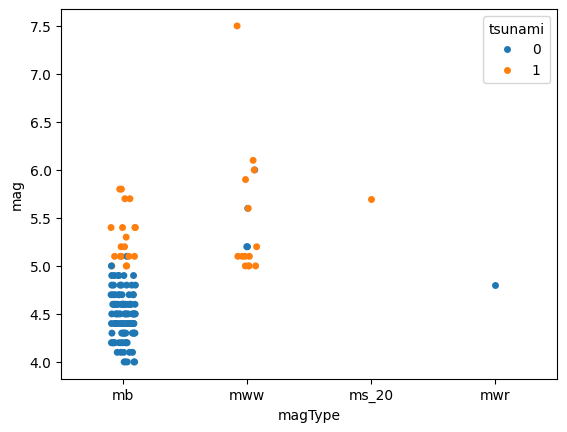

In [9]:
sns.stripplot(
    data=quake_df.query('parsed_place == "Indonesia"'),
    x='magType',
    y='mag',
    hue='tsunami'
)

plt.show()

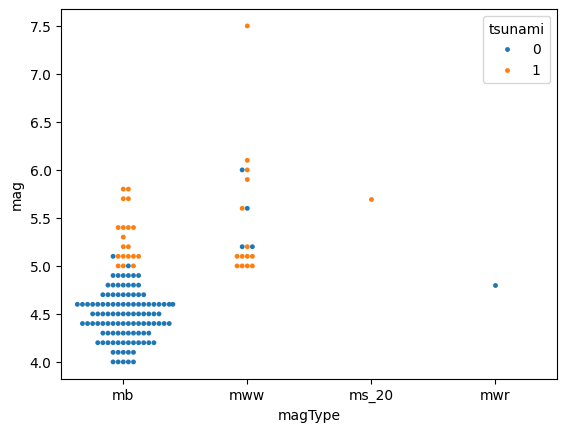

In [11]:
sns.swarmplot(
    data=quake_df.query('parsed_place == "Indonesia"'),
    x='magType',
    y='mag',
    hue='tsunami',
    size=3.5
)

plt.show()

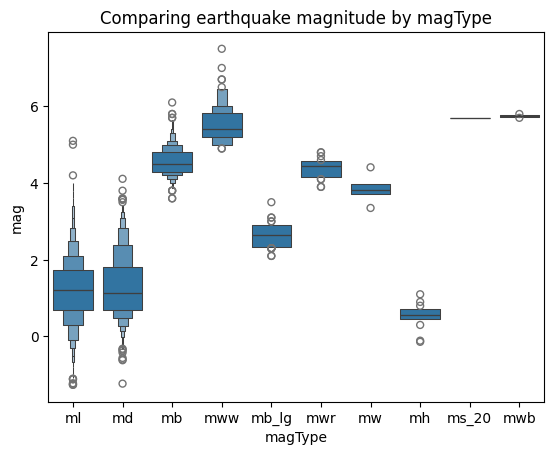

In [12]:
sns.boxenplot(
    data=quake_df[['magType', 'mag']], x='magType', y='mag'
)

plt.title('Comparing earthquake magnitude by magType')
plt.show()

> **Tip :** The enhanced box plot was introduced in the paper Letter-value plots: **Boxplots** for large data, by Heike Hofmann, Karen Kafadar, and Hadley Wickham, which can be found at https://vita.had.co.nz/papers/letter-value-plot.html.

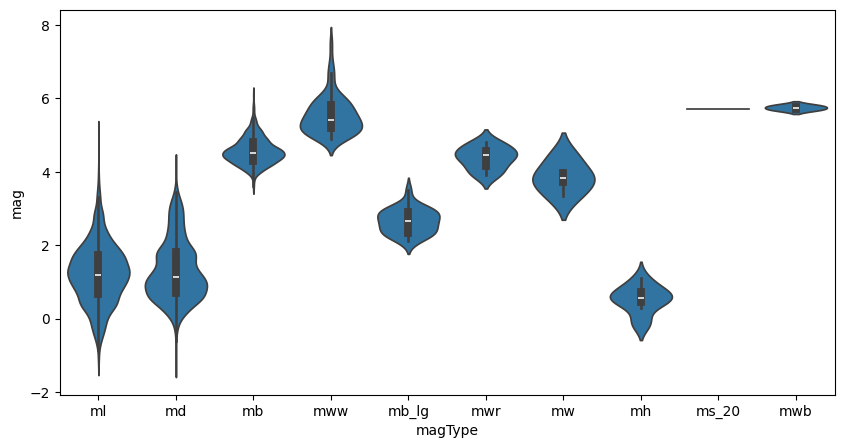

In [15]:
fig, axes = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=quake_df[['magType', 'mag']],
    ax=axes,
    x='magType', y='mag',
    density_norm='width' # all violins have same width
)

plt.title='Comparing earthquake magnitude by magType'
plt.show()

> Be sure to check out the **`countplot()`** and **`barplot()`** functions for variations on the bar plots we created with pandas in the previous chapter.

## **Correlations and heatmaps**

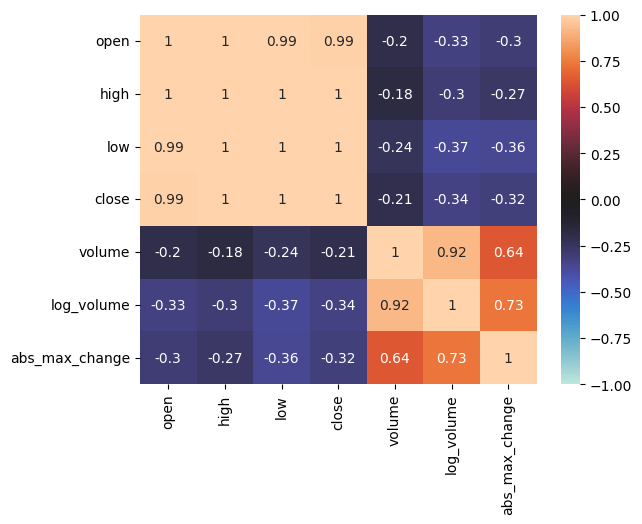

In [16]:
sns.heatmap(
    data=fb_df
        .sort_index()
        .assign(
            log_volume= np.log(fb_df.volume),
            abs_max_change= fb_df.high - fb_df.low
        ).corr(),
    annot=True,
    center=0,
    vmax=1,
    vmin=-1
)

plt.show()

> **Tip :** When using seaborn, we can still use functions from matplotlib, such as **`plt.savefig()`** and **`plt.tight_layout()`**. Note that if there are issues with **`plt.tight_layout()`**, pass **`bbox_inches='tight'`** to **`plt.savefig()`** instead.

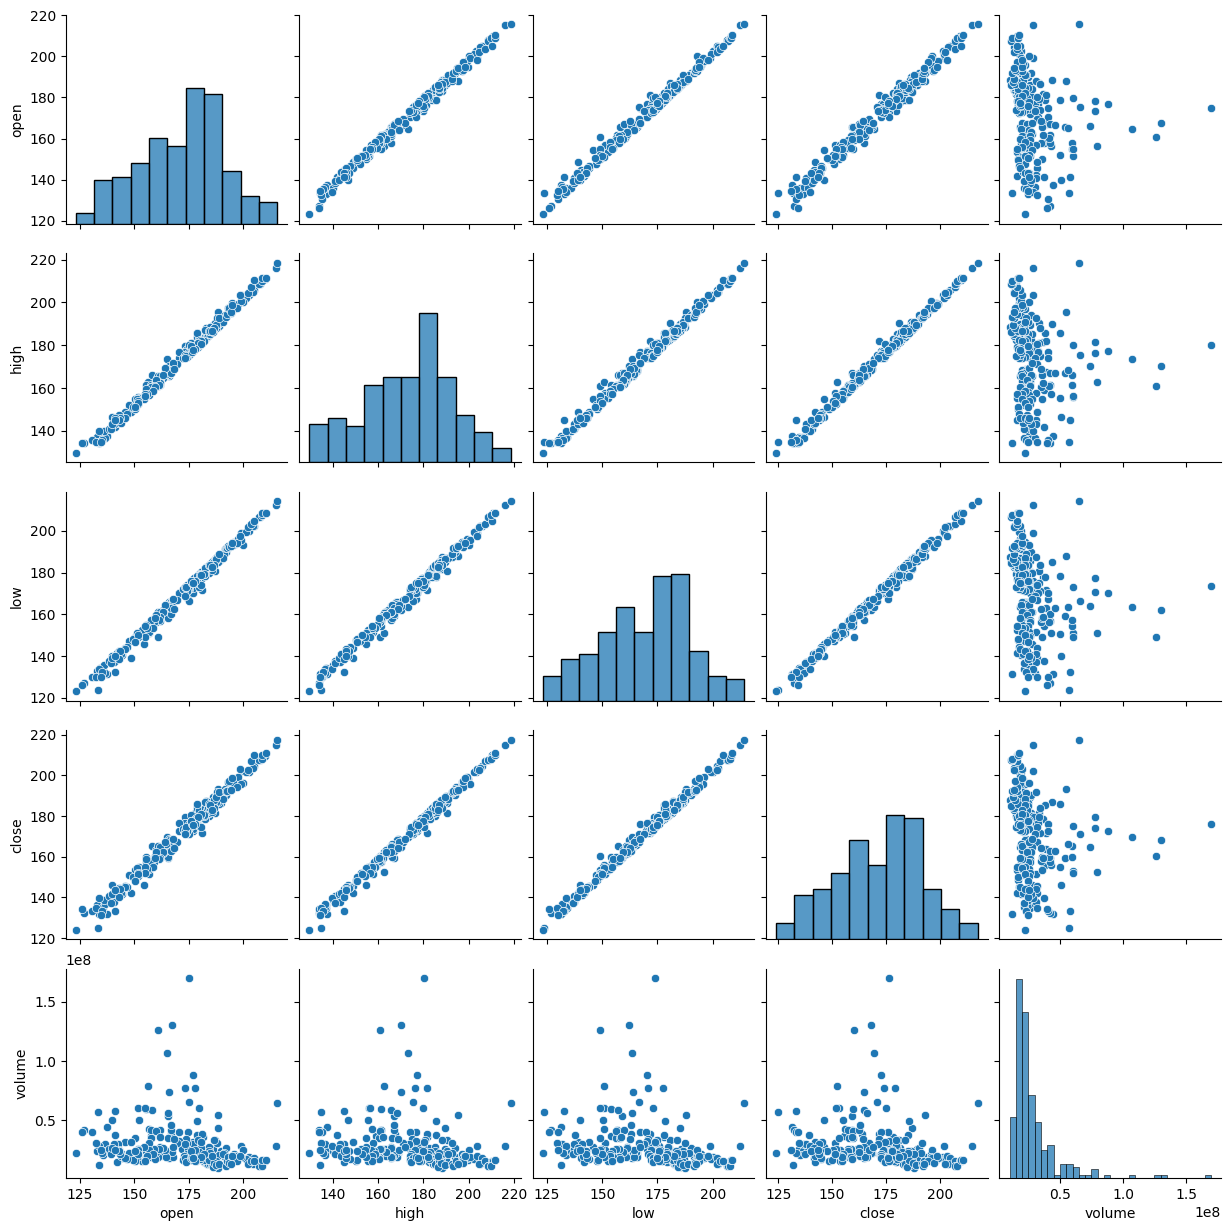

In [18]:
sns.pairplot(fb_df) # Alternative to scatter_matrix in .plotting module in pandas

plt.show()

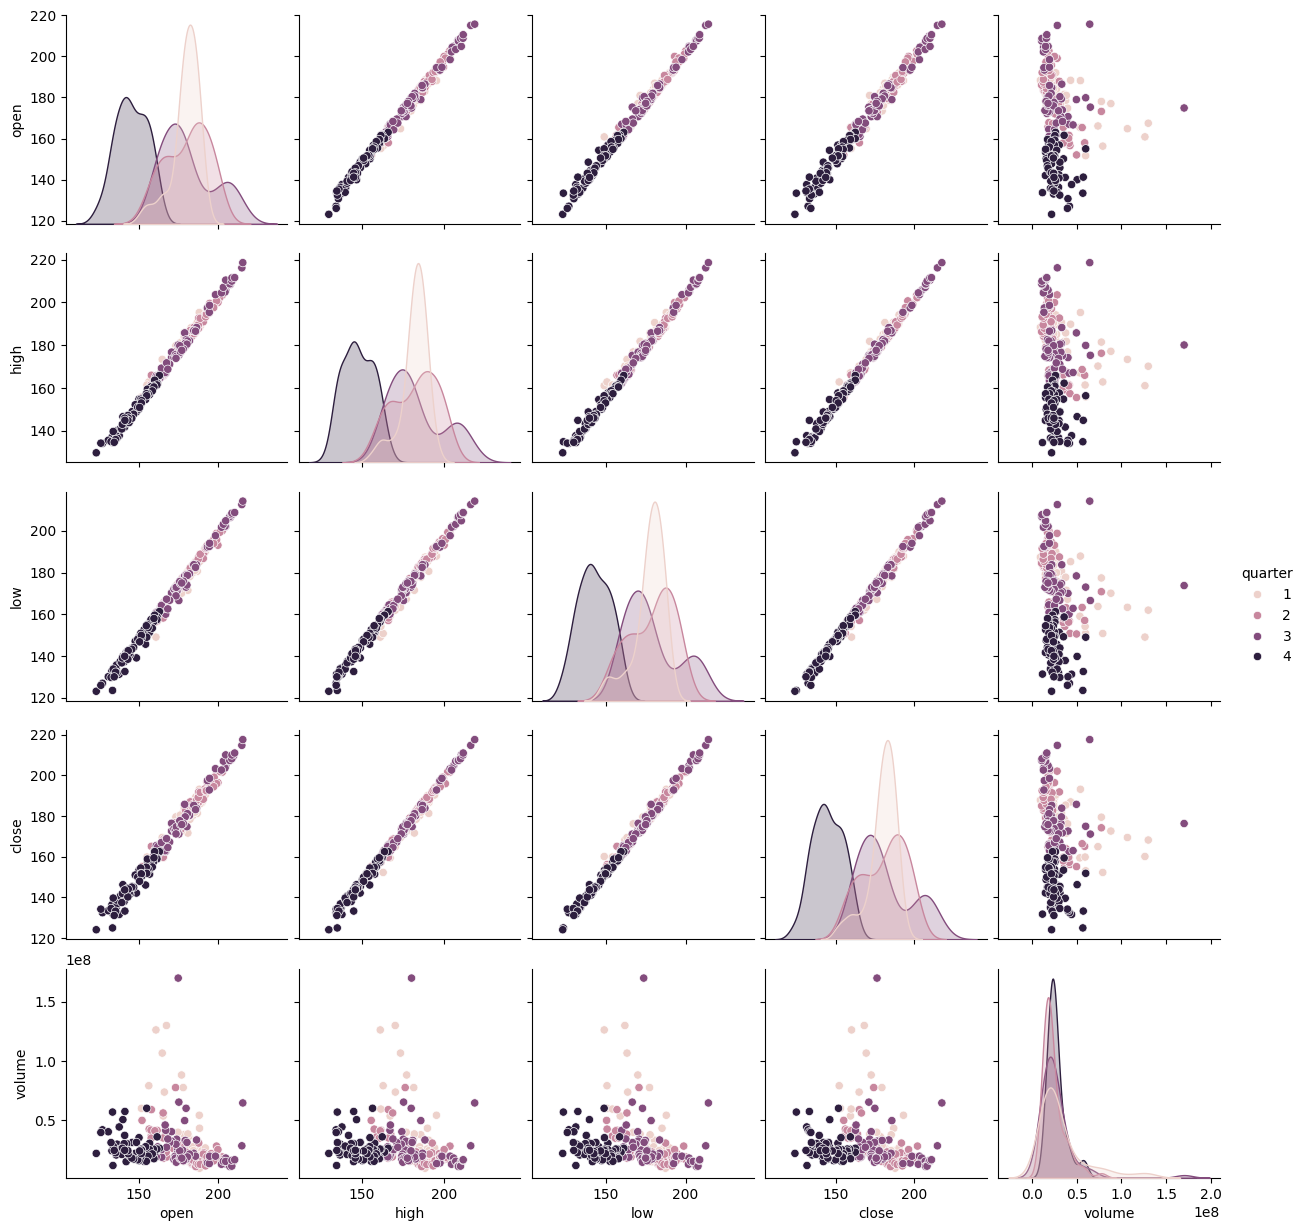

In [20]:
sns.pairplot(
    fb_df.assign(quarter= lambda x: x.index.quarter),
    diag_kind='kde', hue='quarter'
)

plt.show()

> **Tip :** We can also pass kind='reg' to pairplot() to show regression lines.

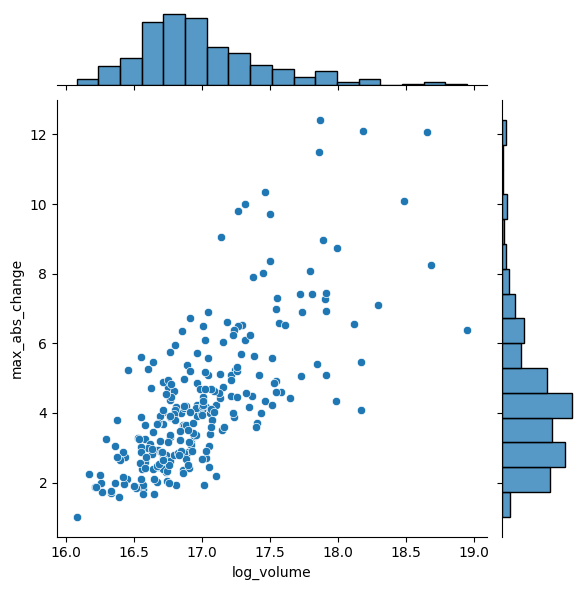

In [21]:
sns.jointplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change=fb_df.high - fb_df.low
    ),
    x='log_volume', y='max_abs_change'
    
)

plt.show()

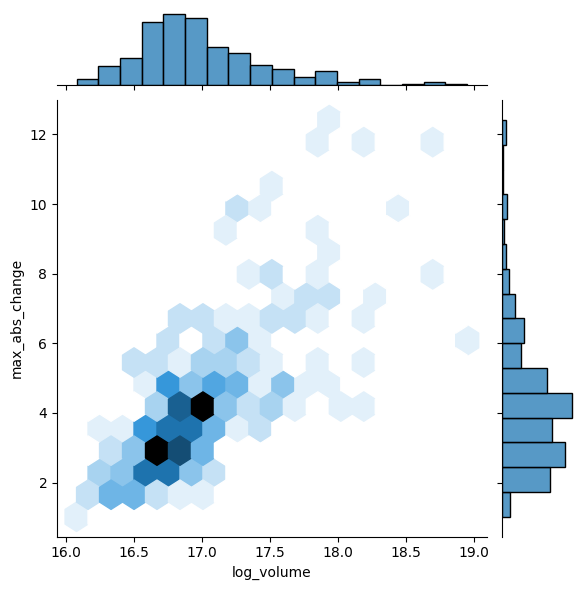

In [22]:
sns.jointplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change= fb_df.high - fb_df.low
    ),
    x='log_volume', y='max_abs_change',
    kind='hex'
)

plt.show()

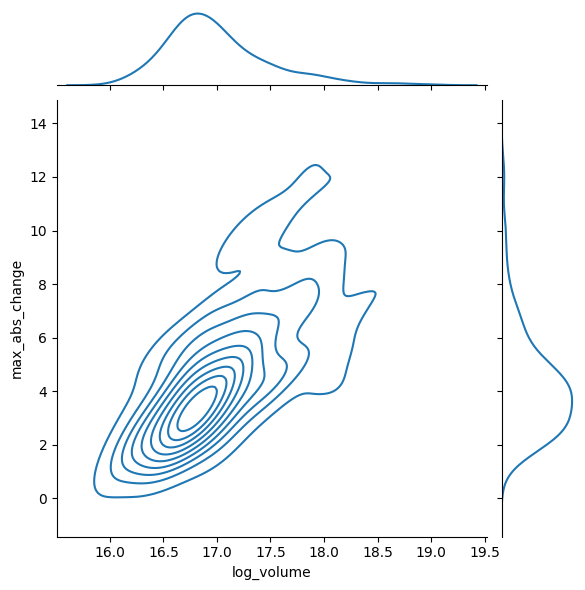

In [23]:
sns.jointplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change= fb_df.high - fb_df.low
    ),
    x='log_volume', y='max_abs_change',
    kind='kde'
)

plt.show()

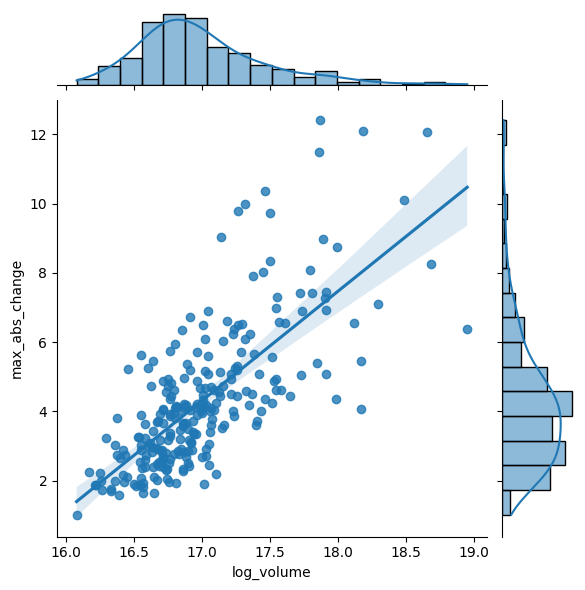

In [24]:
sns.jointplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change= fb_df.high - fb_df.low
    ),
    x='log_volume', y='max_abs_change',
    kind='reg'
)

plt.show()

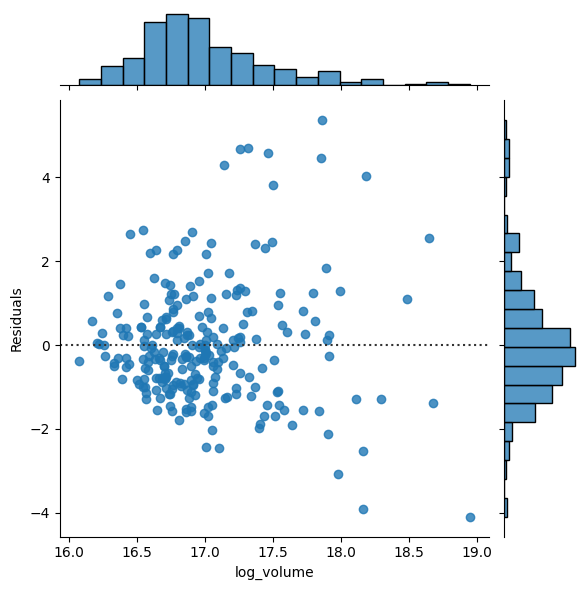

In [25]:
sns.jointplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change= fb_df.high - fb_df.low
    ),
    x='log_volume', y='max_abs_change',
    kind='resid'
)

plt.ylabel('Residuals')
plt.show()

## **Regression plots**

In [28]:
fb_df_reg_data = fb_df.assign(
    log_volume=np.log(fb_df.volume),
    max_abs_change=fb_df.high - fb_df.low
).iloc[:, -2:]

fb_df_reg_data.head()

,log_volume,max_abs_change
date,,
2018-01-02,16.714286,4.03
2018-01-03,16.642029,3.45
2018-01-04,16.446024,2.1104
2018-01-05,16.423706,1.97
2018-01-08,16.705589,2.57


In [29]:
import itertools

In [30]:
iterator = itertools.repeat("I'am an iterator", 1)

In [31]:
for i in iterator:
    print(f'-->{i}')

-->I'am an iterator


In [32]:
for i in iterator:
    print(f'-->{i}') # it print it just once for all and don't for more because it exhausted

In [33]:
iterator

repeat("I'am an iterator", 0)

In [37]:
iterator = list(itertools.repeat("I'am an iterator", 1))

In [38]:
for i in iterator:
    print(f'-->{i}')

-->I'am an iterator


In [41]:
for i in iterator:
    print(f'-->{i}') # This prints again because it's an iterable

-->I'am an iterator


In [40]:
iterator

["I'am an iterator"]

In [50]:
def reg_resid_plots(data):
    """
    Using `seaborn`, plot the regression and residuals plots
    side-by-side for every permutation of 2 columns in data.
    
    Parameters:
    - data: A `pandas.DataFrame` object

    Returns:
    A matplotlib `Axes` object.
    """

    num_cols = data.shape[1]
    permutation_col = num_cols * (num_cols - 1)

    fig, ax = plt.subplots(nrows=permutation_col, ncols=2, figsize=(15, 8))

    for (x, y), axes, color in zip(itertools.permutations(data.columns, 2), ax, itertools.cycle(['royalblue', 'darkorange'])):
        for subplot, func in zip(axes, (sns.regplot, sns.residplot)):
            func(data=data, x=x, y=y, ax=subplot, color=color)
            if func == sns.residplot:
                subplot.set_ylabel('residuals')

    return fig.axes

[<Axes: xlabel='log_volume', ylabel='max_abs_change'>,
 <Axes: xlabel='log_volume', ylabel='residuals'>,
 <Axes: xlabel='max_abs_change', ylabel='log_volume'>,
 <Axes: xlabel='max_abs_change', ylabel='residuals'>]

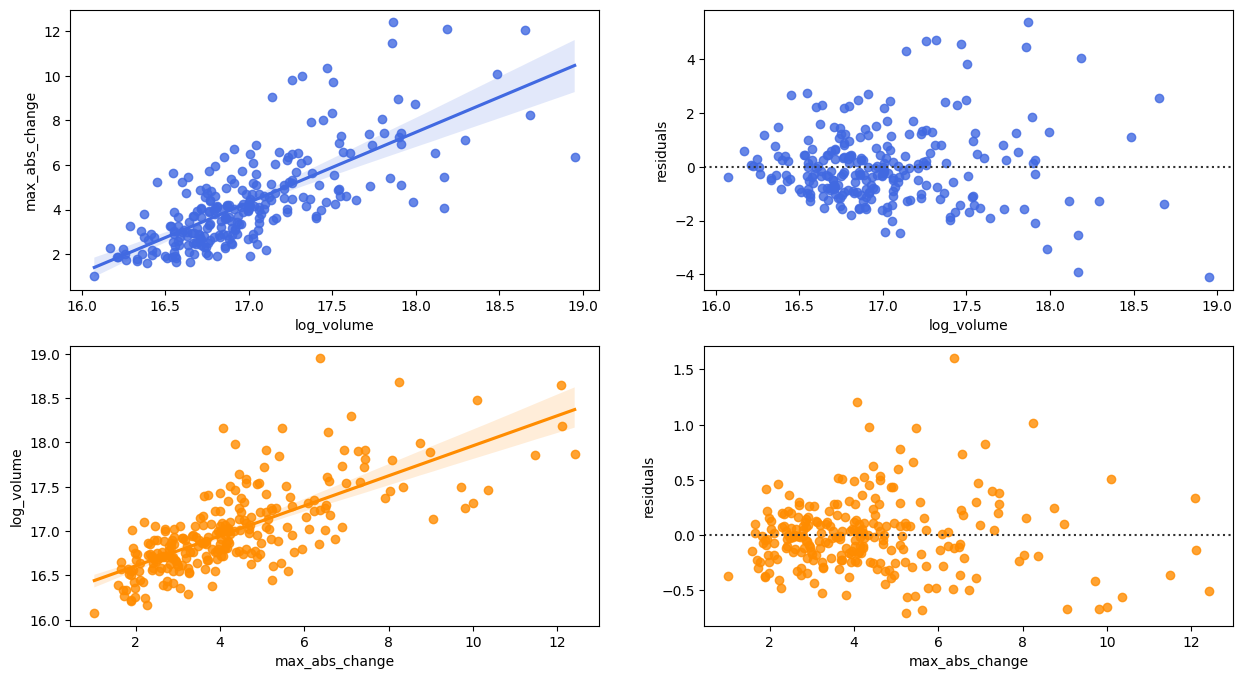

In [51]:
reg_resid_plots(fb_df_reg_data)

> **Tip :** The **`regplot()`** function supports polynomial and logistic regression through the **order** and **logistic** parameters, respectively.

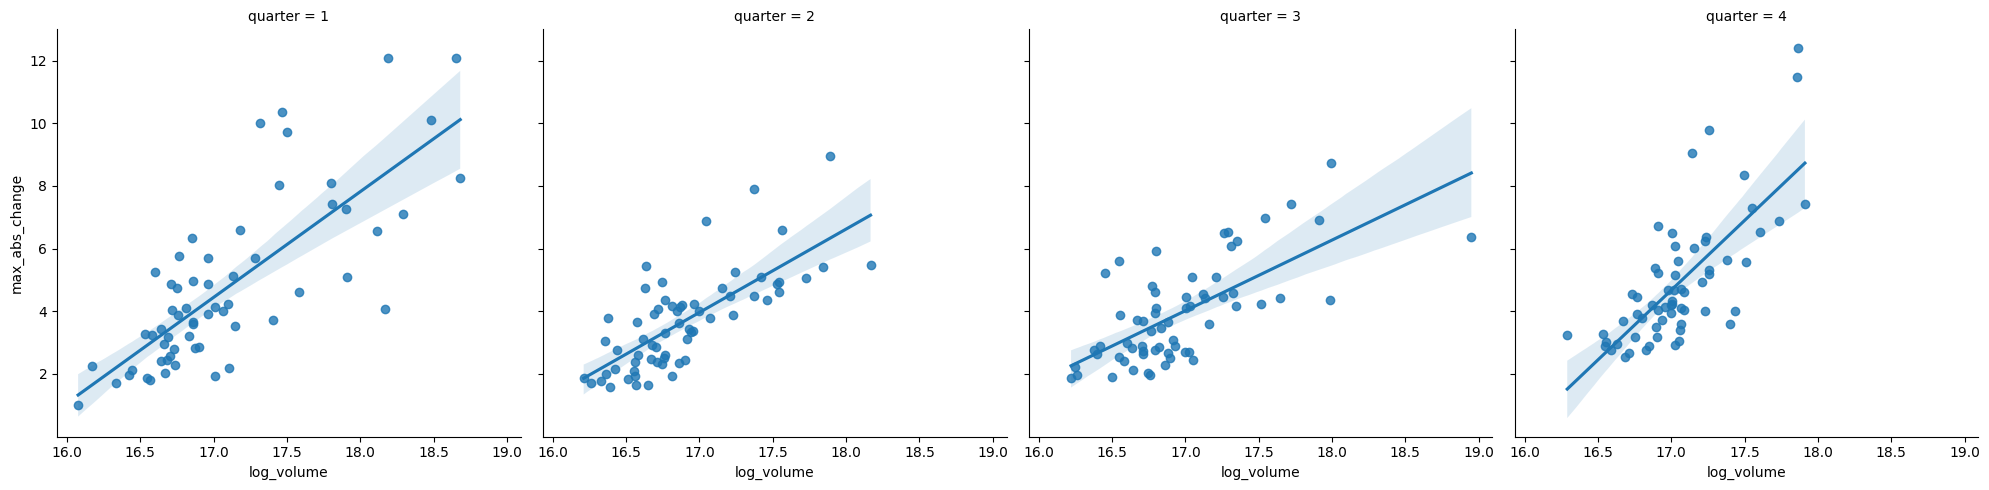

In [52]:
sns.lmplot(
    data=fb_df.assign(
        log_volume=np.log(fb_df.volume),
        max_abs_change=fb_df.high - fb_df.low,
        quarter= lambda x: x.index.quarter 
    ),
    x='log_volume', y='max_abs_change', col='quarter'
)

plt.show()

## **Faceting**

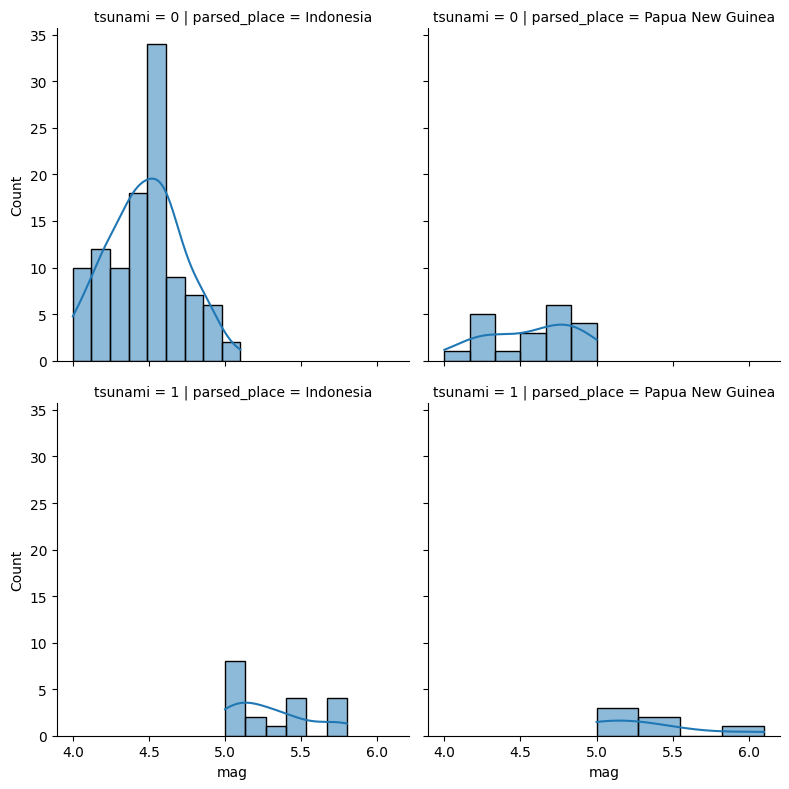

In [57]:
g = sns.FacetGrid(
    quake_df.query(
        'parsed_place.isin(["Indonesia", "Papua New Guinea"])'
        'and magType == "mb"'
    ),
    row='tsunami',
    col='parsed_place',
    height=4
)

g = g.map(sns.histplot, 'mag', kde=True)

# **Formatting plots with matplotlib**